# Fay–Herriot: classical EBLUP

**Navigation**: [← Previous: Direct Estimates](03_direct_estimates.ipynb) | [Next: Bayesian Hierarchical Model →](05_bayesian.ipynb)

REML fit of $\sigma_u^2$, EBLUP shrinkage, Prasad–Rao / Datta–Lahiri MSE, and a delete-one jackknife — the same objects as `sae::eblupFH` / `emdi::fh`.


In [1]:

import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import plotly.express as px
from IPython.display import HTML, display
import warnings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

PROJ_DIR = Path('.').resolve()
if not (PROJ_DIR / 'sae_utils.py').exists():
    PROJ_DIR = Path('projects/small-area-estimation').resolve()
if str(PROJ_DIR) not in sys.path:
    sys.path.insert(0, str(PROJ_DIR))

from sae_utils import (
    load_panel, modelling_frame, design_matrix, eblup_fh, fh_reml_sigma_u,
    jackknife_mse, gibbs_fh, summarise_theta, posterior_predictive_y,
    rhat_split, coverage_rate, project_data_dir,
)

def display_plotly(fig):
    """Embed Plotly with CDN JS — fig.show() is blank in Jupyter Book HTML."""
    display(HTML(fig.to_html(include_plotlyjs='cdn', full_html=False)))

FIG_DIR = PROJ_DIR / 'figures'
FIG_DIR.mkdir(exist_ok=True)
DATA_DIR = project_data_dir()
PANEL = load_panel()
MODEL = modelling_frame(PANEL)
print(f'Panel: {len(PANEL)} local authorities; modelling subset: {len(MODEL)}')
print(f'Period (APS / ONS model-based): {PANEL["direct_period"].dropna().iloc[0]}')


Panel: 348 local authorities; modelling subset: 136
Period (APS / ONS model-based): Apr 2025-Mar 2026


## The frequentist target

Stacking the sampling and linking models gives the marginal

$$
y \mid \beta, \sigma_u^2 \sim N\bigl(X\beta,\; \sigma_u^2 I + \Psi\bigr), \qquad \Psi = \mathrm{diag}(\psi_i).
$$

REML maximises the residual likelihood after projecting out $\beta$ (Rao & Molina, 2015, §5.2). Given $\hat{\sigma}_u^2$, GLS supplies $\hat{\beta}$ and the EBLUP $\hat{\theta}_i = \hat{\gamma}_i y_i + (1-\hat{\gamma}_i) x_i'\hat{\beta}$.

We implement this in `sae_utils.eblup_fh` rather than wrapping R. The algebra is that of `sae::eblupFH(..., method = "REML")` and `emdi::fh(..., method = "reml")`: known $\psi_i$, linear mean, independent random effects. What we **do not** include is emdi's spatial/temporal extensions or automatic transformation of $y$.

In [2]:
fit = eblup_fh(MODEL, covariates=['claimant_rate'])
info = fit.attrs['fit']
print('REML σ²_u = {:.3f}  (σ_u = {:.3f})'.format(info['sigma_u2'], info['sigma_u']))
print('MOM start  = {:.3f}'.format(info['mom_start']))
print('converged  =', info['converged'])
print('Var(σ²_u)  = {:.3f}'.format(info['var_sigma_u2']))
beta = np.array(info['beta'])
for name, b in zip(info['coef_names'], beta):
    print(f'  β[{name}] = {b:.3f}')
print(f"\nmedian γ = {fit['gamma'].median():.3f}  "
      f"min={fit['gamma'].min():.3f}  max={fit['gamma'].max():.3f}")
fit[['GEOGRAPHY_NAME','direct_rate','eblup','gamma','eblup_se','ons_mb_rate']].head(8)


REML σ²_u = 0.956  (σ_u = 0.978)
MOM start  = 1.020
converged  = True
Var(σ²_u)  = 0.075
  β[intercept] = 2.408
  β[claimant_rate] = 0.646

median γ = 0.410  min=0.154  max=0.752


,GEOGRAPHY_NAME,direct_rate,eblup,gamma,eblup_se,ons_mb_rate
0,Barking and Dagenham,6.1,6.921328,0.289883,0.872491,8.2
1,Barnet,5.5,5.593416,0.335095,0.818572,5.9
2,Barnsley,2.6,3.337420,0.620187,0.616751,3.8
3,Bath and North East Somerset,4.6,4.097790,0.478758,0.730763,3.9
4,Bexley,7.3,5.176156,0.211586,0.887394,5.5
5,Birmingham,8.5,8.668065,0.454476,0.796043,8.1
6,Blackburn with Darwen,4.3,5.099809,0.478758,0.726022,5.3
7,Blackpool,4.2,5.355193,0.478758,0.730830,4.7


## MSE: $g_1 + g_2 + 2g_3$

Prasad & Rao (1990) decompose the EBLUP MSE. Datta & Lahiri (2000) show that for REML the leading correction is **twice** $g_3$:

$$
\mathrm{mse}(\hat\theta_i) \approx g_{1i}(\hat\sigma_u^2) + g_{2i}(\hat\sigma_u^2) + 2 g_{3i}(\hat\sigma_u^2),
$$

- $g_1 = \gamma_i \psi_i$ — leading term, the posterior variance if $\beta,\sigma_u^2$ were known;
- $g_2$ — uncertainty in $\hat\beta$;
- $g_3$ — uncertainty in $\hat\sigma_u^2$, involving $\widehat{\mathrm{Var}}(\hat\sigma_u^2) = 2 / \mathrm{tr}(P_V^2)$.

These are **model-based** MSEs. They understate error if the linking model is misspecified, and they ignore uncertainty in $\psi_i$.

In [3]:
print(fit[['eblup_mse','eblup_se']].describe().round(3).to_string())
print('\nMedian SE: direct CI/1.96 vs EBLUP')
print(pd.DataFrame({
    'direct_se': MODEL['direct_rate_ci']/1.96,
    'eblup_se': fit['eblup_se'],
}).median().round(3))


       eblup_mse  eblup_se
count    136.000   136.000
mean       0.601     0.770
std        0.138     0.093
min        0.247     0.497
25%        0.524     0.724
50%        0.598     0.773
75%        0.700     0.837
max        0.895     0.946

Median SE: direct CI/1.96 vs EBLUP
direct_se    1.173
eblup_se     0.773
dtype: float64


## Jackknife MSE

Jiang, Lahiri & Wan (2002) jackknife the EBLUP by deleting one area at a time and refitting $\sigma_u^2$. We report the jackknife **variance of the EBLUP** as a check on $g_1+g_2+2g_3$, not as a replacement: with $m \approx 100$ areas the delete-one perturbation of $\hat\sigma_u^2$ is noisy, and the two estimators can diverge in the tails.

       eblup_se  eblup_se_jack
count   136.000        136.000
mean      0.770          0.150
std       0.093          0.067
min       0.497          0.051
25%       0.724          0.092
50%       0.773          0.135
75%       0.837          0.196
max       0.946          0.393


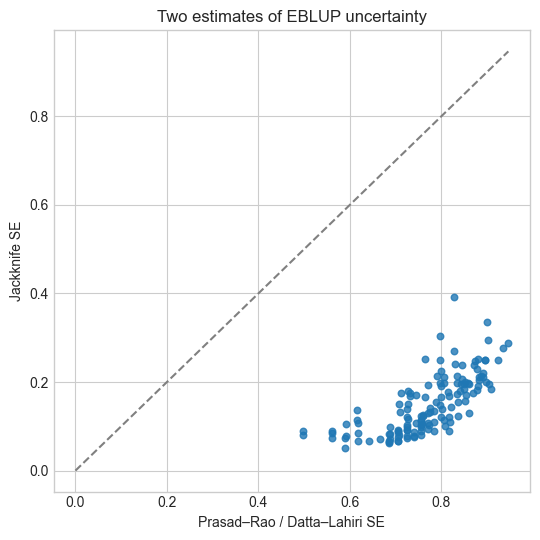

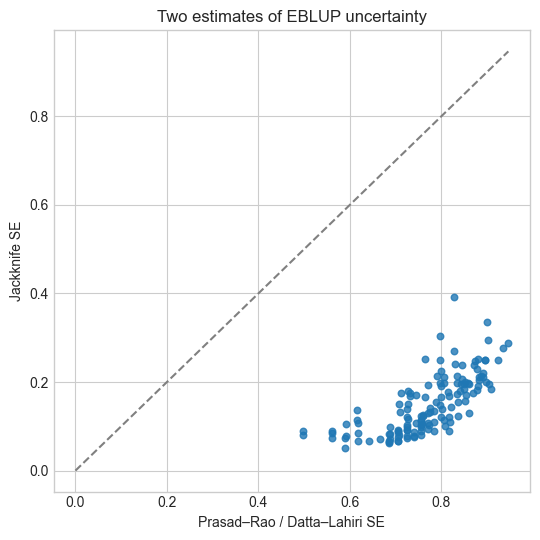

In [4]:
jack_var = jackknife_mse(MODEL, covariates=['claimant_rate'])
fit = fit.copy()
fit['eblup_se_jack'] = np.sqrt(np.maximum(jack_var, 0))
print(fit[['eblup_se','eblup_se_jack']].describe().round(3).to_string())
fig, ax = plt.subplots(figsize=(5.5, 5.5))
ax.scatter(fit['eblup_se'], fit['eblup_se_jack'], s=22, alpha=0.8)
mmax = max(fit['eblup_se'].max(), fit['eblup_se_jack'].max())
ax.plot([0, mmax], [0, mmax], '--', color='grey')
ax.set_xlabel('Prasad–Rao / Datta–Lahiri SE')
ax.set_ylabel('Jackknife SE')
ax.set_title('Two estimates of EBLUP uncertainty')
fig.tight_layout()
fig.savefig(FIG_DIR / '04_mse_jackknife.png', dpi=120)
fig


## Shrinkage in the data

Plot $y_i$ against the EBLUP. Points far from $y=x$ are the areas the model is willing to move; they should be the high-$\psi_i$ ones.

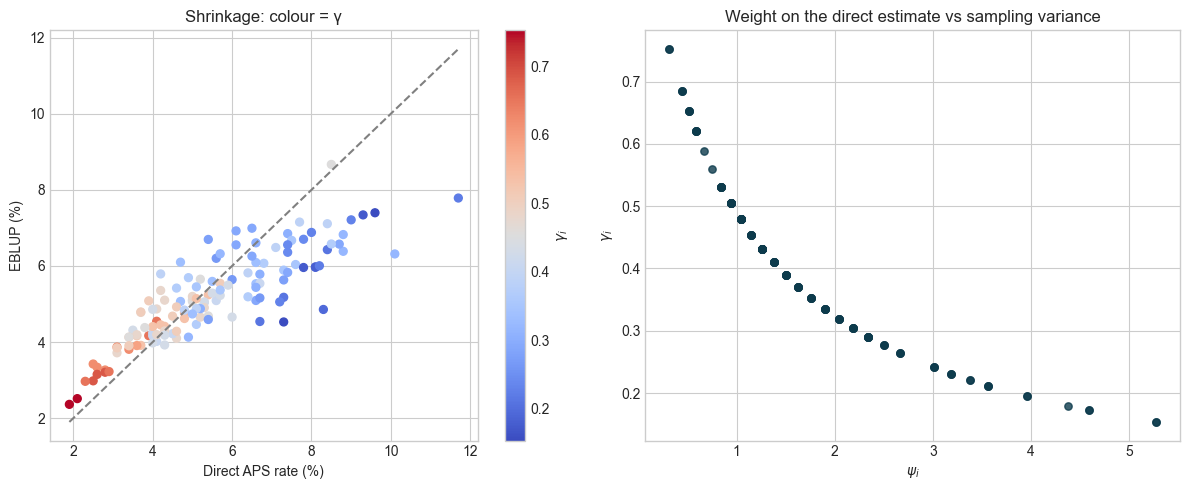

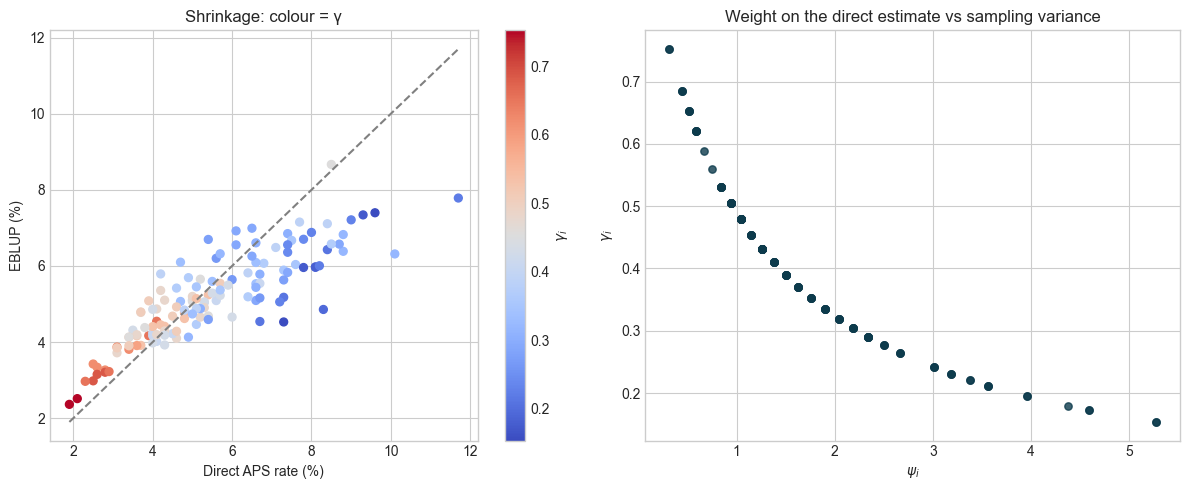

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sc = axes[0].scatter(fit['direct_rate'], fit['eblup'], c=fit['gamma'], cmap='coolwarm', s=32)
lims = [fit[['direct_rate','eblup']].min().min(), fit[['direct_rate','eblup']].max().max()]
axes[0].plot(lims, lims, '--', color='grey')
axes[0].set_xlabel('Direct APS rate (%)')
axes[0].set_ylabel('EBLUP (%)')
axes[0].set_title('Shrinkage: colour = γ')
fig.colorbar(sc, ax=axes[0], label=r'$\gamma_i$')
axes[1].scatter(fit['psi'], fit['gamma'], s=28, alpha=0.8, c='#0d3b4c')
axes[1].set_xlabel(r'$\psi_i$')
axes[1].set_ylabel(r'$\gamma_i$')
axes[1].set_title('Weight on the direct estimate vs sampling variance')
fig.tight_layout()
fig.savefig(FIG_DIR / '04_shrinkage.png', dpi=120)
fig


## Adding inactivity

A second covariate (APS inactivity) is itself a survey estimate, so it violates the 'known $x$' assumption. We fit it as a sensitivity check, not as the preferred specification. If $\hat\sigma_u^2$ barely moves, claimant count already absorbs most of the between-area signal.

In [6]:
m2 = MODEL.dropna(subset=['inactivity_rate']).copy()
fit2 = eblup_fh(m2, covariates=['claimant_rate', 'inactivity_rate'])
i2 = fit2.attrs['fit']
print('claimant-only σ²_u = {:.3f}'.format(info['sigma_u2']))
print('claimant+inactivity σ²_u = {:.3f}'.format(i2['sigma_u2']))
print('coefficients:', dict(zip(i2['coef_names'], np.round(i2['beta'], 3))))


claimant-only σ²_u = 0.956
claimant+inactivity σ²_u = 0.970
coefficients: {'intercept': np.float64(2.252), 'claimant_rate': np.float64(0.635), 'inactivity_rate': np.float64(0.009)}


## Key takeaways

- REML $\hat\sigma_u^2$ determines the **global** amount of borrowing; $\psi_i$ then allocates it locally via $\gamma_i$.
- Datta–Lahiri MSE is the analytic default; the jackknife is a useful disagreement diagnostic, not an automatic upgrade.
- Treating a survey covariate as $x_i$ is a specification error — keep the production-style model to claimant count.

---

**Navigation**: [← Previous: Direct Estimates](03_direct_estimates.ipynb) | [Next: Bayesian Hierarchical Model →](05_bayesian.ipynb)
